# Showcase per la spline

In [171]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
from src.models.shape.closed_spline import ClosedSpline

from shapely.geometry import LineString

from src.utils import _tolerated_mcd

In [172]:
# Definizione dei parametri geometrici
# Definiamo l'origine locale per le trasformazioni (solitamente 0,0)
riferimento_per_le_trasformazioni = (0.0, 0.0)

# Coordinate (x, y) dei vertici in senso antiorario (CCW)
punti_di_controllo = [
    (-00., 20.),
    (30., 30.),
    (40., -20.),
    (0., -50.),
    (-30., 10.)
]

# Generazione della forma
# La classe Shape incapsula i punti e genera l'oggetto geometrico
forma_generica = ClosedSpline(
    punti_di_controllo
)

In [173]:
# Analisi delle Proprietà
print("--- PROPRIETÀ GEOMETRICHE ---")
print(f"Vertici originari:\n{forma_generica.control_points}")

# È in questo esatto momento che scatta il calcolo lazy del baricentro.
# Nelle chiamate successive, il valore verrà recuperato istantaneamente dalla cache.
print(f"Baricentro: {forma_generica.barycenter}")
print(f"Origine (Rif. standard): {forma_generica.origin}\n")

print("--- VERIFICA PRECISIONE MATEMATICA ---")
# Anche Area, Lunghezza e Bounds vengono calcolati on-demand tramite Shapely
print(f"Area Shapely: {forma_generica.area:.4f}")
print(f"Perimetro Shapely: {forma_generica.length:.4f}")
print(f"Bounds (BBox): {forma_generica.bounds}")
print(f"Verso di percorrenza dei vertici (CCW): {forma_generica.ccw}")

--- PROPRIETÀ GEOMETRICHE ---
Vertici originari:
[ 0.13043642 20.21866458  0.14660732 ...  0.13043642 20.21866458
  0.13043642]
Baricentro: [14.86019996 -9.15997115]
Origine (Rif. standard): [0. 0.]

--- VERIFICA PRECISIONE MATEMATICA ---
Area Shapely: 3563.9535
Perimetro Shapely: 219.9238
Bounds (BBox): (-13.220084225871444, -50.75092313032426, 44.08987782888905, 30.840911317514323)
Verso di percorrenza dei vertici (CCW): False


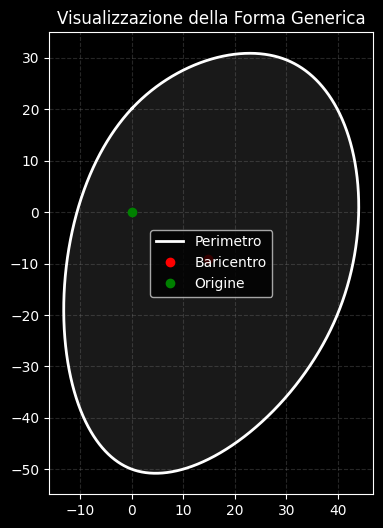

In [174]:
# Inizializzazione della figura: l'aspetto 'equal' è fondamentale in geometria
fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.set_aspect('equal') # Evita distorsioni visive (1 unità X = 1 unità Y)
ax1.grid(True, linestyle='--', alpha=0.3, color='gray')
ax1.set_title("Visualizzazione della Forma Generica")

# Plot del perimetro e riempimento
# L'operatore * (unpacking) separa le tuple (X, Y) generate da Shapely nei due argomenti richiesti da plot()
ax1.plot(*forma_generica.shapely.exterior.xy, color='white', linewidth=2, label="Perimetro")
ax1.fill(*forma_generica.shapely.exterior.xy, color='gray', alpha=0.2) # Aggiunge volume visivo

# Plot dei punti notevoli (recuperati istantaneamente dalla cache)
ax1.plot(*forma_generica.barycenter, color='red', marker='o', linestyle='', label="Baricentro")
ax1.plot(*forma_generica.origin, color='green', marker='o', linestyle='', label="Origine")

ax1.legend()
plt.show()

In [175]:
# Analisi dei parametri di discretizzazione (Calcolati on-demand tramite lazy caching)
print(f"Step minimo consentito: {forma_generica.min_discretization_step}")
print(f"Step massimo (MCD dei segmenti): {forma_generica.max_discretization_step}")
print(f"Lista dei passi sicuri calcolati: {forma_generica.sure_steps}")

# Proviamo a forzare un passo arbitrario.
# Il setter della proprietà intercetta questo valore.
# Se 4.5 non è un "sure step", lo arrotonderà al passo sicuro più vicino per evitare deformazioni!
forma_generica.discretization_step = 10

print(f"Step effettivamente impostato dalla classe: {forma_generica.discretization_step}")

Step minimo consentito: 0.1
Step massimo (MCD dei segmenti): 73.3079339412598
Lista dei passi sicuri calcolati: None
Step effettivamente impostato dalla classe: 10.0


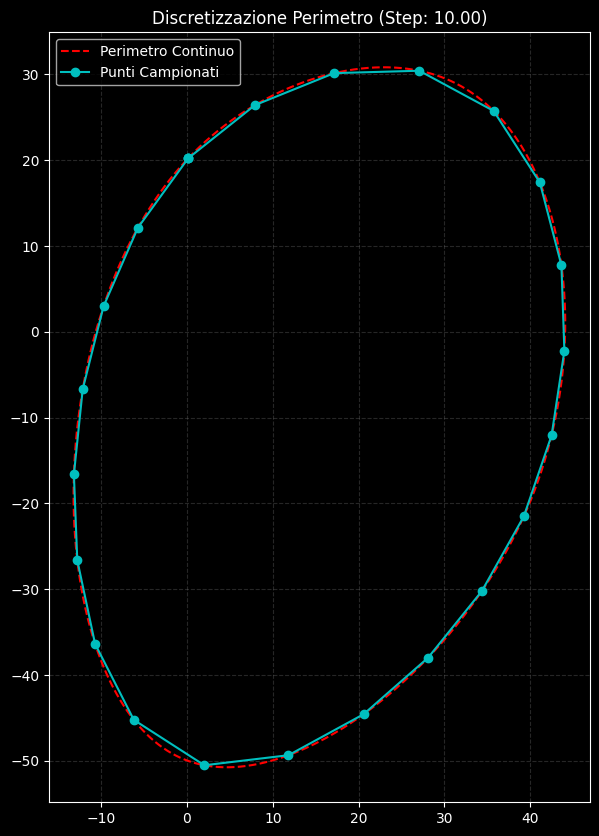

In [176]:
# Generiamo l'array numpy con le coordinate dei punti discretizzati lungo il perimetro
chiusura = forma_generica.discretize()

# Per chiudere visivamente il loop nel grafico, aggiungiamo il primo punto alla fine dell'array
chiusura = np.vstack((chiusura, chiusura[0]))

# Estraiamo le colonne X e Y per Matplotlib
x, y = chiusura[:, 0], chiusura[:, 1]

# Impostiamo il grafico
fig5, ax5 = plt.subplots(figsize=(10, 10)) # Ridotto da 20x20 per comodità di lettura a schermo
ax5.set_aspect('equal')
ax5.grid(True, linestyle='--', alpha=0.3, color='gray')
ax5.set_title(f"Discretizzazione Perimetro (Step: {forma_generica.discretization_step:.2f})")

# Plottiamo la sagoma continua in background (Rossa tratteggiata)
ax5.plot(*forma_generica.shapely.exterior.xy, color='red', linestyle='--', label="Perimetro Continuo")

# Plottiamo i punti campionati (Ciano)
ax5.plot(x, y, linestyle='-', color='c', marker='o', markersize=6, label="Punti Campionati")

ax5.legend()
plt.show()

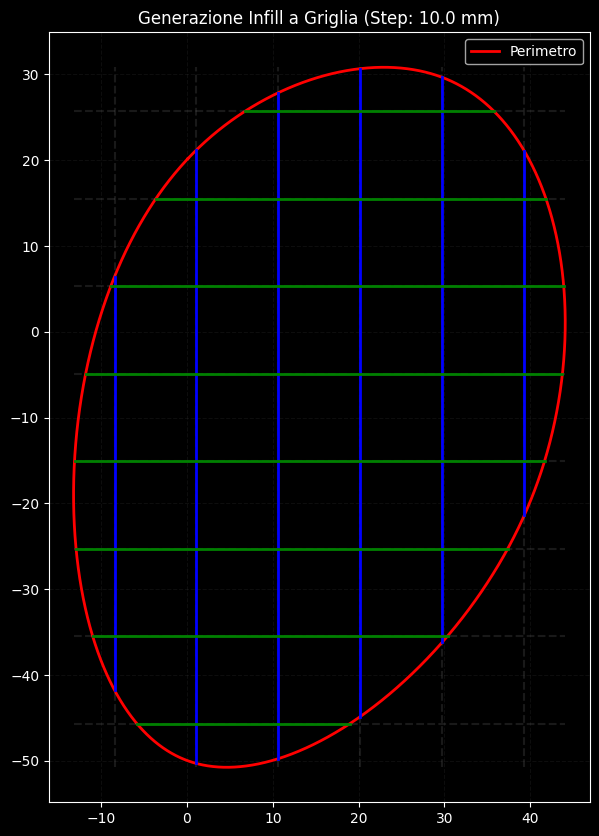

In [177]:
# 1. Estrazione dei limiti (Bounding Box)
x_0, y_0, x_f, y_f = forma_generica.bounds

# 2. Impostazione parametri griglia
grid_step = 10.0
# offset_padding = 20.0 # (Opzionale, non lo stavi usando ma puoi usarlo per restringere la griglia)

# Calcolo del numero di linee necessarie
n_x = int(np.round((x_f - x_0) / grid_step))
n_y = int(np.round((y_f - y_0) / grid_step))

linee_interne_verticali = []
linee_interne_orizzontali = []

# 3. Setup Grafico
fig6, ax6 = plt.subplots(figsize=(10, 10))
ax6.set_aspect('equal')
ax6.grid(True, linestyle='--', alpha=0.1, color='gray')
ax6.set_title(f"Generazione Infill a Griglia (Step: {grid_step} mm)")

poly = forma_generica.shapely

# PLOT FONDAMENTALE: Disegniamo il perimetro rosso per dare contesto visivo
ax6.plot(*poly.exterior.xy, color='red', linewidth=2, label="Perimetro")

# 4. Generazione Linee Verticali
passo_x = (x_f - x_0) / n_x if n_x > 0 else grid_step
for i in range(n_x):
    x_curr = passo_x / 2 + x_0 + i * passo_x
    linea_vert = LineString([(x_curr, y_0), (x_curr, y_f)])

    # Disegniamo la linea di costruzione "infinita" in grigio chiaro
    ax6.plot(*linea_vert.xy, '--', color='grey', alpha=0.2)

    # Intersezione (Sintassi corretta: un solo argomento)
    intersezione = poly.intersection(linea_vert)

    if not intersezione.is_empty:
        # GESTIONE SICURA: Separiamo i casi in cui la linea viene spezzata (forme concave)
        if intersezione.geom_type == 'MultiLineString':
            for segmento in intersezione.geoms:
                linee_interne_verticali.append(segmento)
                ax6.plot(*segmento.xy, '-b', linewidth=2) # Linee blu interne
        elif intersezione.geom_type == 'LineString':
            linee_interne_verticali.append(intersezione)
            ax6.plot(*intersezione.xy, '-b', linewidth=2)

# 5. Generazione Linee Orizzontali (Completato)
passo_y = (y_f - y_0) / n_y if n_y > 0 else grid_step
for i in range(n_y):
    y_curr = passo_y / 2 + y_0 + i * passo_y
    linea_hor = LineString([(x_0, y_curr), (x_f, y_curr)])

    ax6.plot(*linea_hor.xy, '--', color='grey', alpha=0.2)

    intersezione = poly.intersection(linea_hor)

    if not intersezione.is_empty:
        if intersezione.geom_type == 'MultiLineString':
            for segmento in intersezione.geoms:
                linee_interne_orizzontali.append(segmento)
                ax6.plot(*segmento.xy, '-g', linewidth=2) # Linee verdi interne
        elif intersezione.geom_type == 'LineString':
            linee_interne_orizzontali.append(intersezione)
            ax6.plot(*intersezione.xy, '-g', linewidth=2)

ax6.legend()
plt.show()

In [178]:

testa = np.column_stack((chiusura, np.zeros(chiusura.shape[0])))
coda = np.zeros_like(testa) - np.asarray([0, 0, 1], dtype=float)

contorno = np.round(np.hstack((testa, coda)), decimals=3)

interno = []
quota_sicurezza = 50.0 # Z di svincolo

for linea in linee_interne_verticali:
    x, y = linea.xy

    segmento_interno = np.column_stack((x, y, np.zeros(len(x))))

    punto_entrata = np.round(np.array([segmento_interno[0] + [0, 0, quota_sicurezza]], dtype=float), decimals=3)
    punto_uscita = np.round(np.array([segmento_interno[-1] + [0, 0, quota_sicurezza]], dtype=float), decimals=3)

    interno.append(punto_entrata)
    interno.append(segmento_interno)
    interno.append(punto_uscita)

testa_infill_3d_vert = np.round(np.vstack(interno), 3)
coda_infill_3d_vert = np.round(np.zeros_like(testa_infill_3d_vert) - np.asarray([0, 0, 1], dtype=float), 3)

percorso_infill_3d_vert = np.round(np.hstack((testa_infill_3d_vert, coda_infill_3d_vert)), 3)

entrata_contorno = np.round(contorno[0] + np.asarray([0, 0, quota_sicurezza, 0, 0, 0], dtype=float), 3)
uscita_contorno = np.round(contorno[-1] + np.asarray([0, 0, quota_sicurezza, 0, 0, 0], dtype=float), 3)

In [179]:
offset = np.array([850, 350, 60, 0, 0, 0], dtype=np.float64)

contorno_finale = contorno + offset
entrata_contorno_f = entrata_contorno + offset
uscita_contorno_f = uscita_contorno + offset

interno_finale = np.round(percorso_infill_3d_vert, decimals=3) + offset

for coord in interno_finale:
    riga = ""
    for x in coord:
        if x is coord[-1]:
            riga = riga + f"{x}\n"
        else:
            riga = riga + f"{x}, "
    print(riga)

841.556, 308.242, 110.0, 0.0, 0.0, -1.0, 
841.556, 308.242, 60.0, 0.0, 0.0, -1.0, 
841.556, 356.438, 60.0, 0.0, 0.0, -1.0, 
841.556, 356.438, 110.0, 0.0, 0.0, -1.0, 
851.107, 299.69100000000003, 110.0, 0.0, 0.0, -1.0, 
851.107, 299.69100000000003, 60.0, 0.0, 0.0, -1.0, 
851.107, 371.213, 60.0, 0.0, 0.0, -1.0, 
851.107, 371.213, 110.0, 0.0, 0.0, -1.0, 
860.659, 300.255, 110.0, 0.0, 0.0, -1.0, 
860.659, 300.255, 60.0, 0.0, 0.0, -1.0, 
860.659, 377.88, 60.0, 0.0, 0.0, -1.0, 
860.659, 377.88, 110.0, 0.0, 0.0, -1.0, 
870.211, 305.16700000000003, 110.0, 0.0, 0.0, -1.0, 
870.211, 305.16700000000003, 60.0, 0.0, 0.0, -1.0, 
870.211, 380.683, 60.0, 0.0, 0.0, -1.0, 
870.211, 380.683, 110.0, 0.0, 0.0, -1.0, 
879.762, 313.835, 110.0, 0.0, 0.0, -1.0, 
879.762, 313.835, 60.0, 0.0, 0.0, -1.0, 
879.762, 379.662, 60.0, 0.0, 0.0, -1.0, 
879.762, 379.662, 110.0, 0.0, 0.0, -1.0, 
889.314, 328.612, 110.0, 0.0, 0.0, -1.0, 
889.314, 328.612, 60.0, 0.0, 0.0, -1.0, 
889.314, 371.099, 60.0, 0.0, 0.0, -1.0, 
889.

In [180]:
riga = ""
for x in entrata_contorno_f:
    if x is entrata_contorno_f[-1]:
        riga = riga + f"{x}\n"
    else:
        riga = riga + f"{x}, "
print(riga)
for coord in contorno_finale:
    riga = ""
    for x in coord:
        if x is coord[-1]:
            riga = riga + f"{x}\n"
        else:
            riga = riga + f"{x}, "
    print(riga)
riga = ""
for x in uscita_contorno_f:
    if x is uscita_contorno_f[-1]:
        riga = riga + f"{x}\n"
    else:
        riga = riga + f"{x}, "
print(riga)

850.13, 370.219, 110.0, 0.0, 0.0, -1.0, 
850.13, 370.219, 60.0, 0.0, 0.0, -1.0, 
857.923, 376.428, 60.0, 0.0, 0.0, -1.0, 
867.156, 380.158, 60.0, 0.0, 0.0, -1.0, 
877.073, 380.438, 60.0, 0.0, 0.0, -1.0, 
885.742, 375.757, 60.0, 0.0, 0.0, -1.0, 
891.131, 367.416, 60.0, 0.0, 0.0, -1.0, 
893.646, 357.768, 60.0, 0.0, 0.0, -1.0, 
893.99, 347.794, 60.0, 0.0, 0.0, -1.0, 
892.497, 337.923, 60.0, 0.0, 0.0, -1.0, 
889.255, 328.481, 60.0, 0.0, 0.0, -1.0, 
884.363, 319.778, 60.0, 0.0, 0.0, -1.0, 
878.091, 312.008, 60.0, 0.0, 0.0, -1.0, 
870.582, 305.431, 60.0, 0.0, 0.0, -1.0, 
861.833, 300.657, 60.0, 0.0, 0.0, -1.0, 
852.025, 299.484, 60.0, 0.0, 0.0, -1.0, 
843.806, 304.774, 60.0, 0.0, 0.0, -1.0, 
839.288, 313.634, 60.0, 0.0, 0.0, -1.0, 
837.213, 323.396, 60.0, 0.0, 0.0, -1.0, 
836.82, 333.375, 60.0, 0.0, 0.0, -1.0, 
837.847, 343.311, 60.0, 0.0, 0.0, -1.0, 
840.282, 352.997, 60.0, 0.0, 0.0, -1.0, 
844.283, 362.142, 60.0, 0.0, 0.0, -1.0, 
850.13, 370.219, 60.0, 0.0, 0.0, -1.0, 
850.13, 370.219, 60.

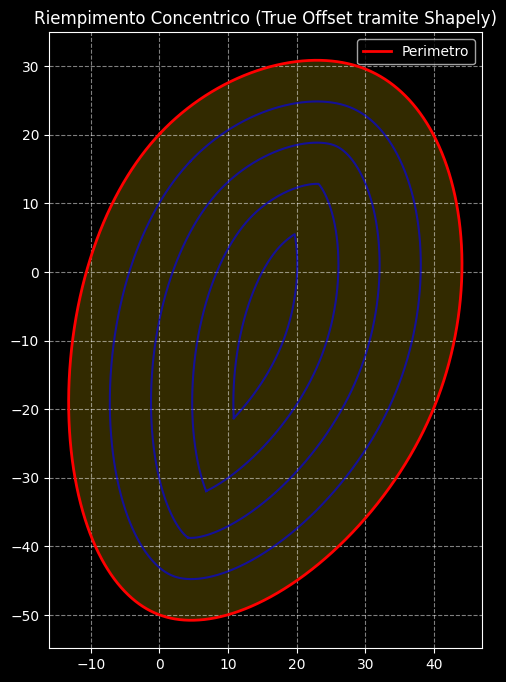

In [181]:
fig7, ax7 = plt.subplots(figsize=(6, 8))
ax7.set_aspect('equal')
ax7.grid(True, linestyle='--', alpha=0.5)
ax7.set_title("Riempimento Concentrico (True Offset tramite Shapely)")

x_ext, y_ext =forma_generica.shapely.exterior.xy
ax7.plot(x_ext, y_ext, '-r', linewidth=2, label="Perimetro")
ax7.fill(x_ext, y_ext, color='gold', alpha=0.2)

offset_assoluto = 6
ciclo = 0

poly_succession = []
current_poly = forma_generica.shapely
while True:
    current_poly = current_poly.buffer(-offset_assoluto, join_style=2)
    if current_poly.is_empty:
        break

    ciclo += 1
    if current_poly.geom_type == 'Polygon':
        polygons = [current_poly]
    elif current_poly.geom_type == 'MultiPolygon':
        polygons = current_poly.geoms
    else:
        break

    for poly in polygons:
        x_int, y_int = poly.exterior.xy
        ax7.plot(x_int, y_int, '-b', alpha=0.6)

    print(f"Ciclo {ciclo:02d} | Area rimanente: {current_poly.area:.2f}")

ax7.legend()
plt.show()